# Round 1 — Exploratory Data Analysis

Products: `ASH_COATED_OSMIUM`, `INTARIAN_PEPPER_ROOT`  
Days: -2, -1, 0

Sections:
1. Load & clean data
2. Mid-price time series
3. Rolling mean & std
4. Autocorrelation (lags 1–10)
5. Stationarity verdict (ADF test)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from statsmodels.tsa.stattools import adfuller

DATA = Path('../data/round1')
DAYS = [-2, -1, 0]
ROLL = 50  # rolling window (timestamps)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load & clean

In [2]:
frames = []
for day in DAYS:
    path = DATA / f'prices_round_1_day_{day}.csv'
    df = pd.read_csv(path, sep=';')
    df['day'] = day
    frames.append(df)

prices = pd.concat(frames, ignore_index=True)

# Create a monotonic global timestamp: each day has 1,000,000 ticks
prices['global_ts'] = (prices['day'] + 2) * 1_000_000 + prices['timestamp']
prices.sort_values(['product', 'global_ts'], inplace=True)
prices.reset_index(drop=True, inplace=True)

products = sorted(prices['product'].unique())
print(f'Products : {products}')
print(f'Rows     : {len(prices):,}')
prices.head()

Products : ['ASH_COATED_OSMIUM', 'INTARIAN_PEPPER_ROOT']
Rows     : 60,000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_ts
0,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,0
1,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,100
2,-2,200,ASH_COATED_OSMIUM,9992.0,15.0,9989.0,30.0,NaN,NaN,10008.0,15.0,10010.0,30.0,NaN,NaN,10000.0,0.0,200
3,-2,300,ASH_COATED_OSMIUM,9992.0,13.0,9989.0,26.0,NaN,NaN,10008.0,13.0,10010.0,26.0,NaN,NaN,10000.0,0.0,300
4,-2,400,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10010.0,20.0,NaN,NaN,10000.0,0.0,400


## 2. Mid-price time series

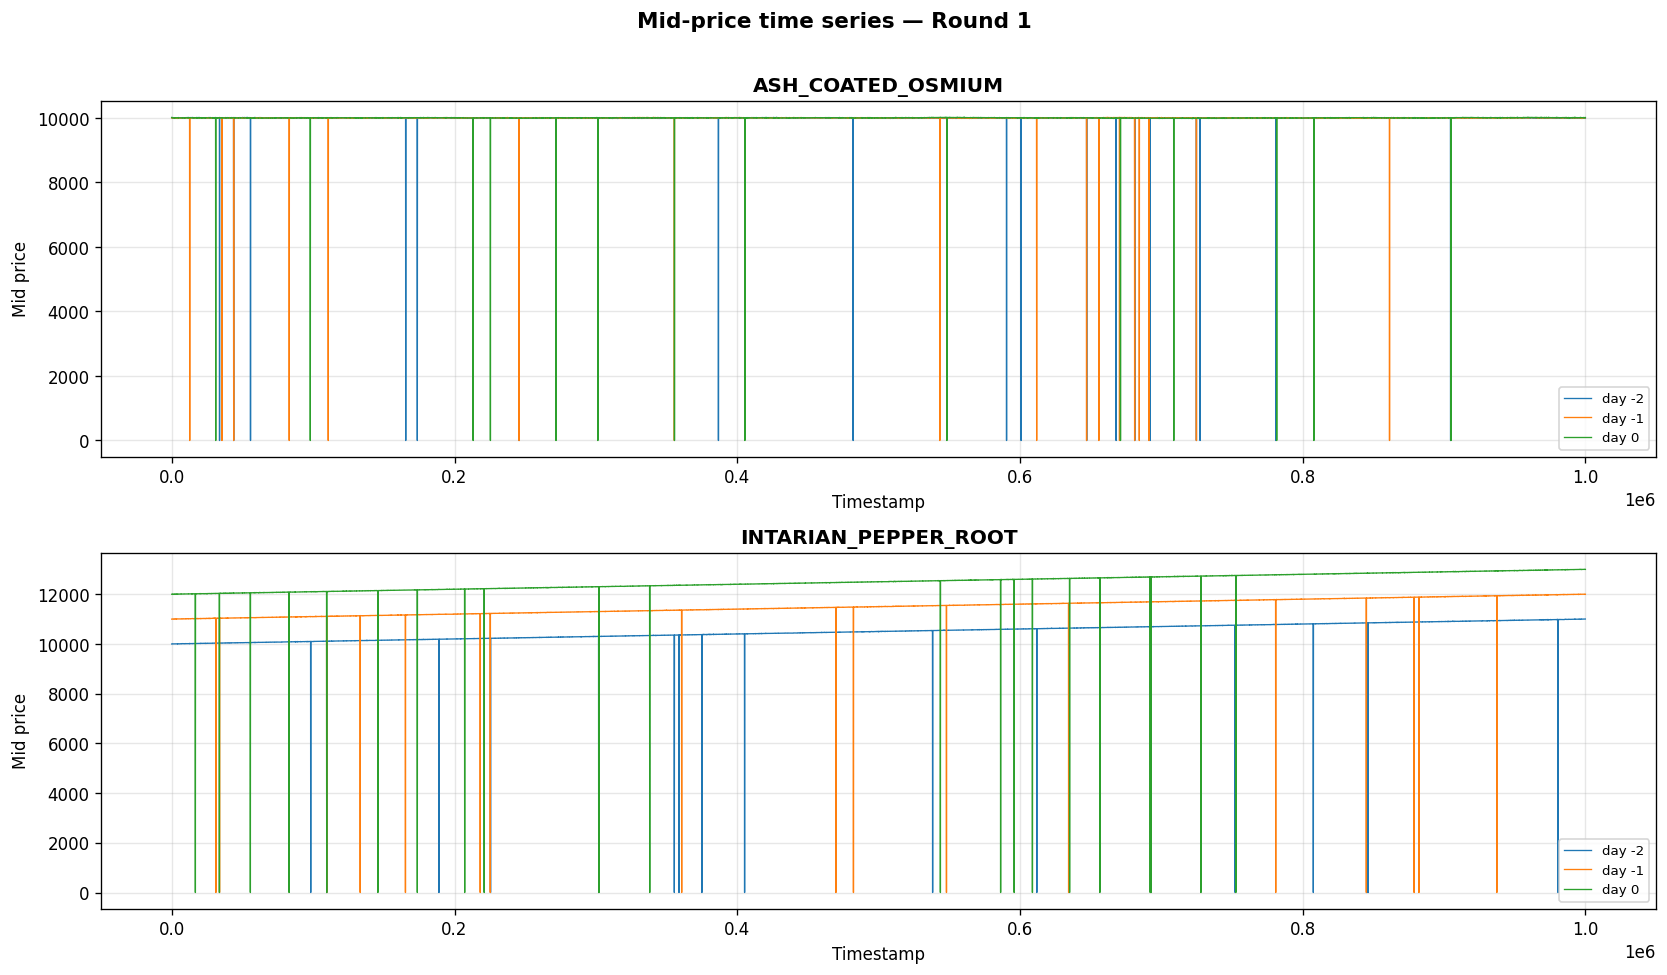

In [3]:
fig, axes = plt.subplots(len(products), 1, figsize=(14, 4 * len(products)), squeeze=False)

for ax, product in zip(axes[:, 0], products):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day]
        ax.plot(d['timestamp'], d['mid_price'], lw=0.8, label=f'day {day}')
    ax.set_title(product, fontweight='bold')
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid price')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Mid-price time series — Round 1', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3. Rolling mean & standard deviation

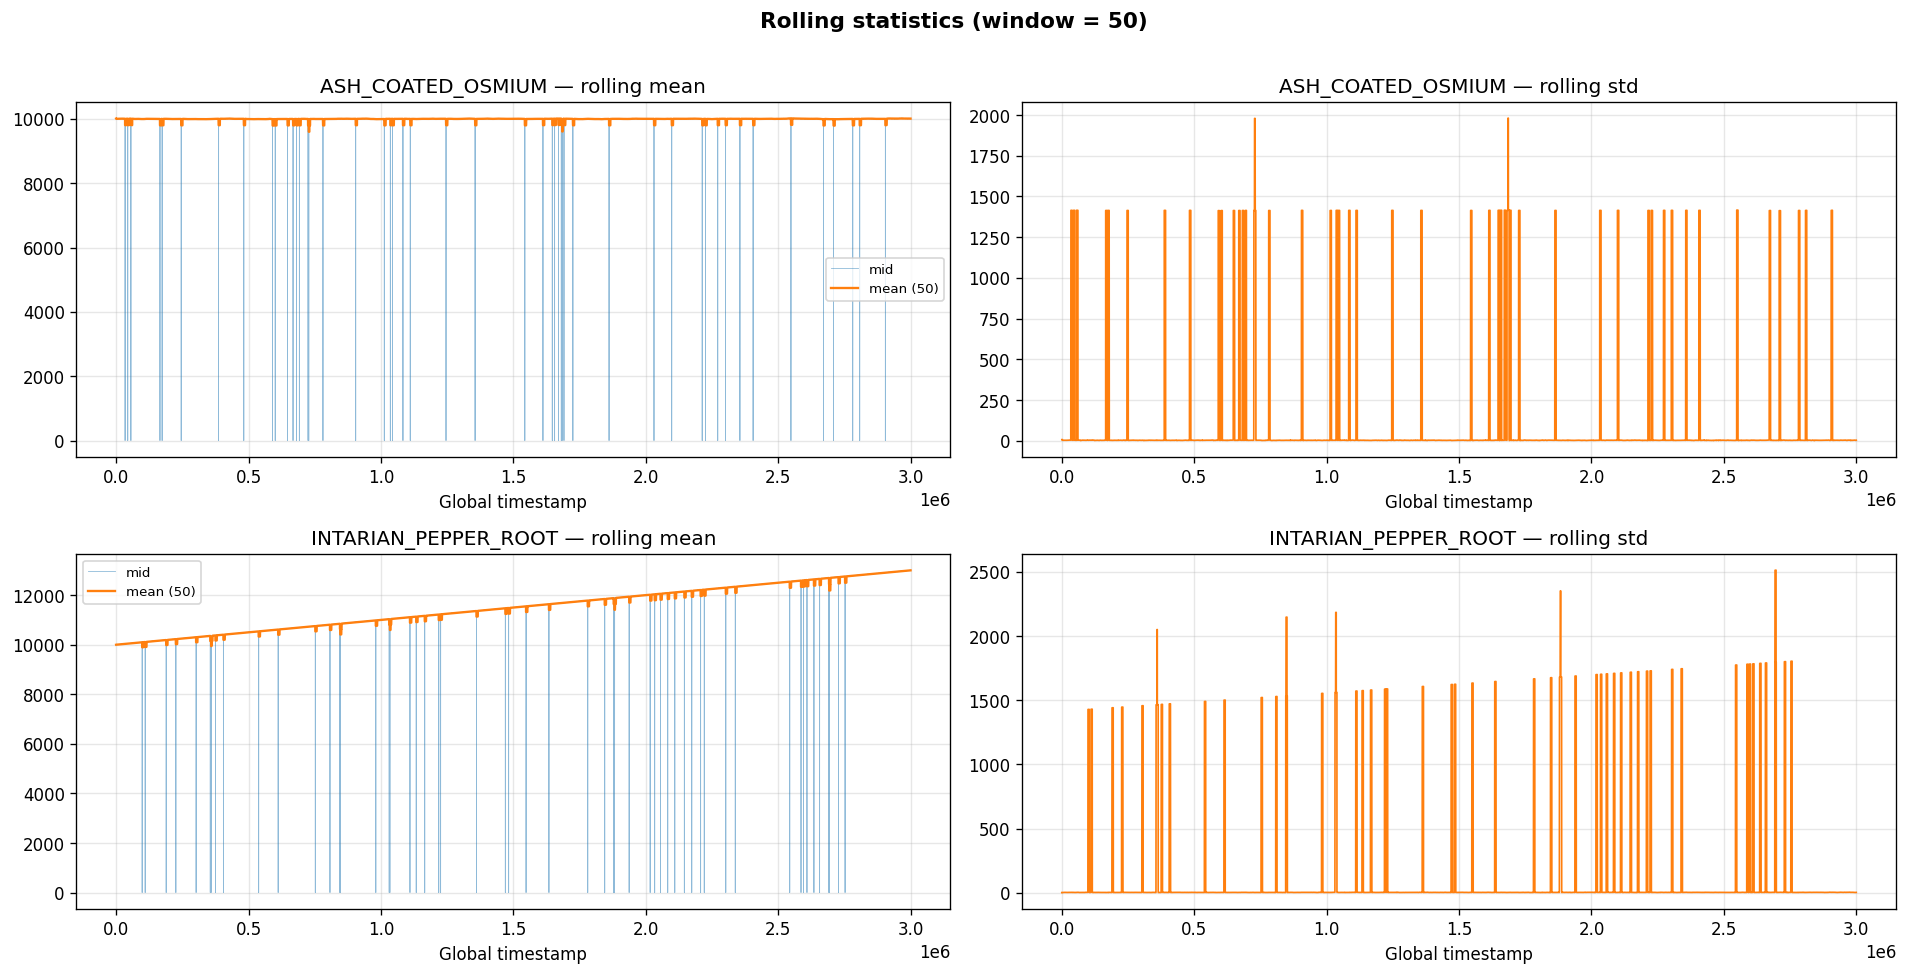

In [4]:
fig, axes = plt.subplots(len(products), 2, figsize=(16, 4 * len(products)), squeeze=False)

for row, product in enumerate(products):
    sub = prices[prices['product'] == product].copy()
    sub['roll_mean'] = sub['mid_price'].rolling(ROLL, min_periods=1).mean()
    sub['roll_std']  = sub['mid_price'].rolling(ROLL, min_periods=1).std()

    ax_m, ax_s = axes[row, 0], axes[row, 1]

    # Rolling mean
    ax_m.plot(sub['global_ts'], sub['mid_price'], lw=0.5, alpha=0.5, label='mid')
    ax_m.plot(sub['global_ts'], sub['roll_mean'], lw=1.4, label=f'mean ({ROLL})')
    ax_m.set_title(f'{product} — rolling mean')
    ax_m.set_xlabel('Global timestamp')
    ax_m.legend(fontsize=8)
    ax_m.grid(alpha=0.3)

    # Rolling std
    ax_s.plot(sub['global_ts'], sub['roll_std'], color='tab:orange', lw=1.0)
    ax_s.set_title(f'{product} — rolling std')
    ax_s.set_xlabel('Global timestamp')
    ax_s.grid(alpha=0.3)

plt.suptitle(f'Rolling statistics (window = {ROLL})', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Autocorrelation at lags 1–10

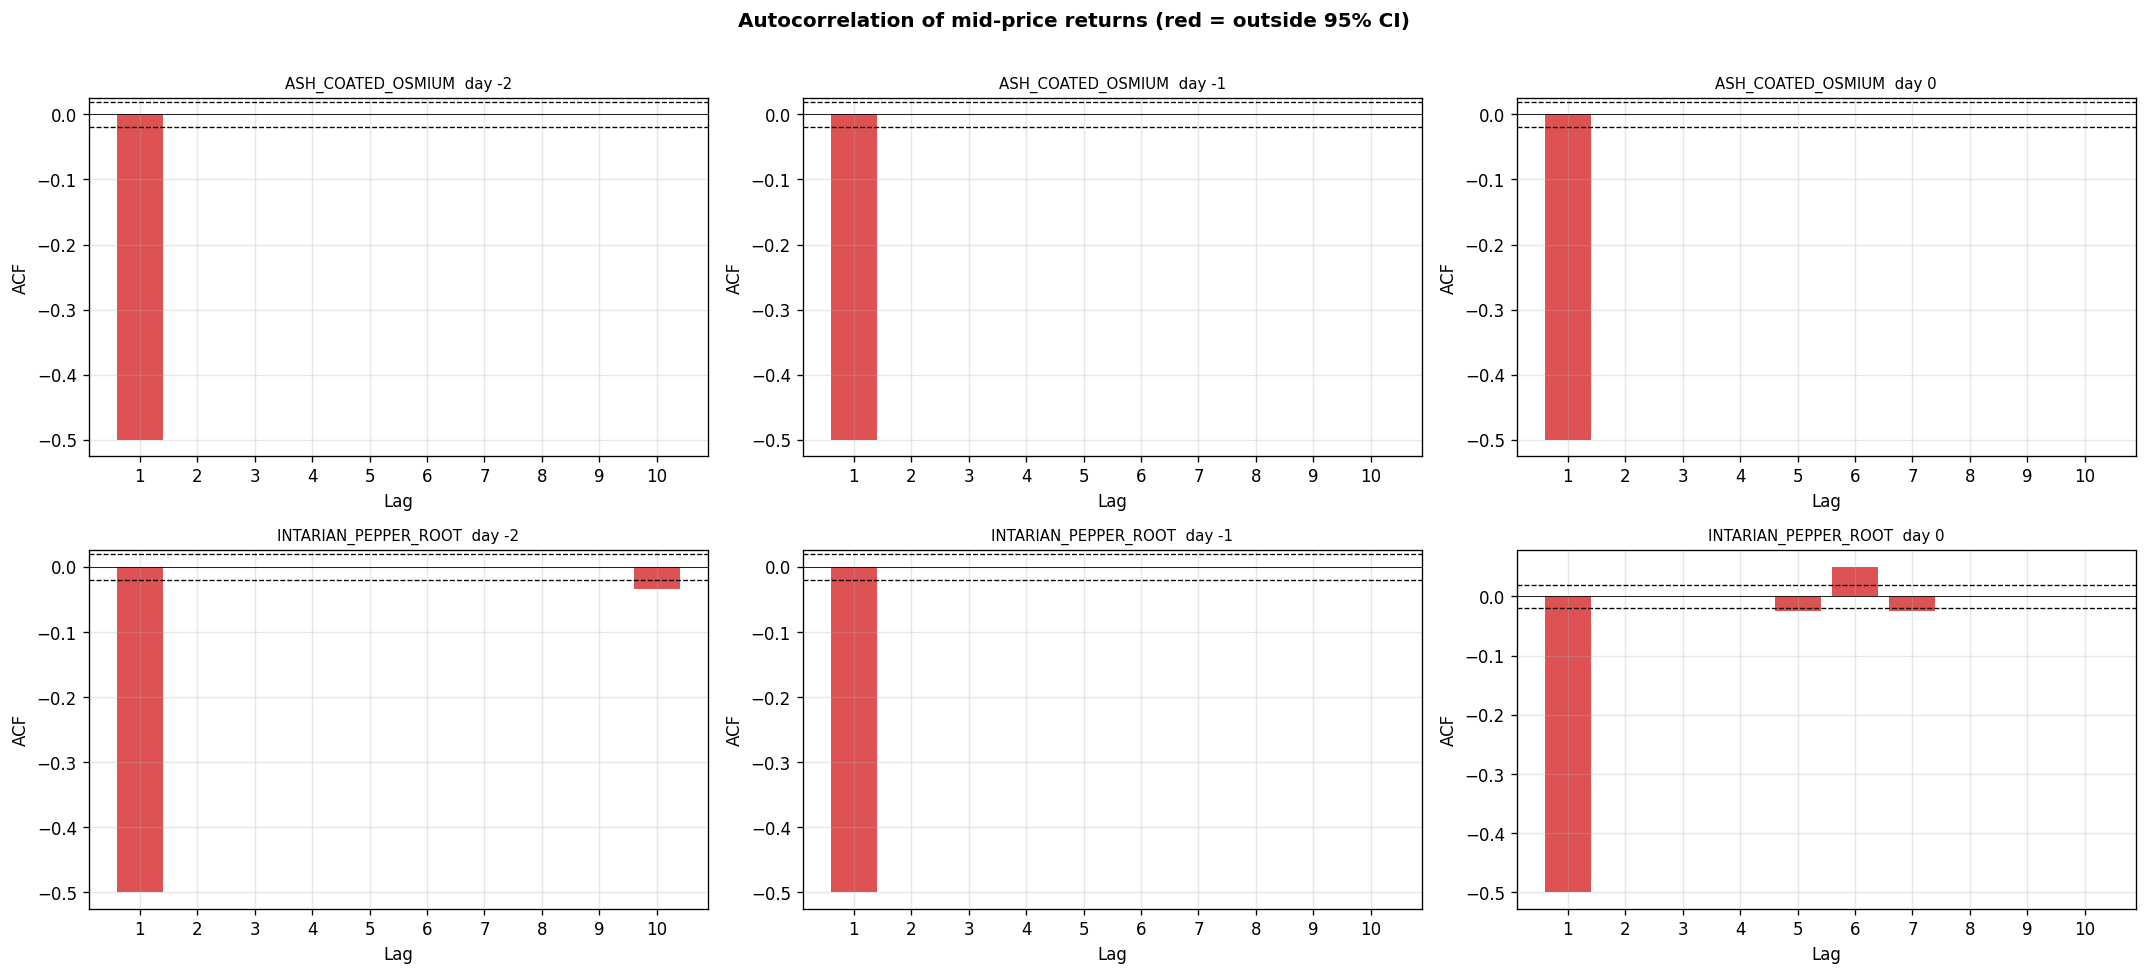

In [5]:
MAX_LAG = 10

fig, axes = plt.subplots(len(products), len(DAYS), figsize=(6 * len(DAYS), 4 * len(products)), squeeze=False)

for row, product in enumerate(products):
    for col, day in enumerate(DAYS):
        ax = axes[row, col]
        series = prices[(prices['product'] == product) & (prices['day'] == day)]['mid_price'].dropna()
        returns = series.diff().dropna()  # autocorrelate returns, not levels

        lags = range(1, MAX_LAG + 1)
        acf_vals = [returns.autocorr(lag=l) for l in lags]
        conf = 1.96 / np.sqrt(len(returns))  # 95% CI

        colors = ['tab:red' if abs(v) > conf else 'tab:blue' for v in acf_vals]
        ax.bar(list(lags), acf_vals, color=colors, alpha=0.8)
        ax.axhline(conf,  color='k', ls='--', lw=0.8)
        ax.axhline(-conf, color='k', ls='--', lw=0.8)
        ax.axhline(0,     color='k', lw=0.5)
        ax.set_title(f'{product}  day {day}', fontsize=9)
        ax.set_xlabel('Lag')
        ax.set_ylabel('ACF')
        ax.set_xticks(list(lags))
        ax.grid(alpha=0.3)

plt.suptitle('Autocorrelation of mid-price returns (red = outside 95% CI)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Stationarity — ADF test & verdict

In [6]:
results = []

for product in products:
    # Test on all-day combined series
    series = prices[prices['product'] == product]['mid_price'].dropna()
    adf_stat, p_val, _, _, crit, _ = adfuller(series, autolag='AIC')
    verdict = 'STATIONARY' if p_val < 0.05 else 'TRENDING / UNIT ROOT'
    results.append({
        'product': product,
        'ADF statistic': round(adf_stat, 4),
        'p-value': round(p_val, 6),
        '1%': round(crit['1%'], 3),
        '5%': round(crit['5%'], 3),
        '10%': round(crit['10%'], 3),
        'verdict': verdict
    })

adf_df = pd.DataFrame(results).set_index('product')
print(adf_df.to_string())
adf_df

                      ADF statistic   p-value     1%     5%    10%               verdict
product                                                                                 
ASH_COATED_OSMIUM         -173.4983  0.000000 -3.431 -2.862 -2.567            STATIONARY
INTARIAN_PEPPER_ROOT        -1.9139  0.325559 -3.431 -2.862 -2.567  TRENDING / UNIT ROOT


,ADF statistic,p-value,1%,5%,10%,verdict
product,,,,,,
ASH_COATED_OSMIUM,-173.4983,0.000000,-3.431,-2.862,-2.567,STATIONARY
INTARIAN_PEPPER_ROOT,-1.9139,0.325559,-3.431,-2.862,-2.567,TRENDING / UNIT ROOT


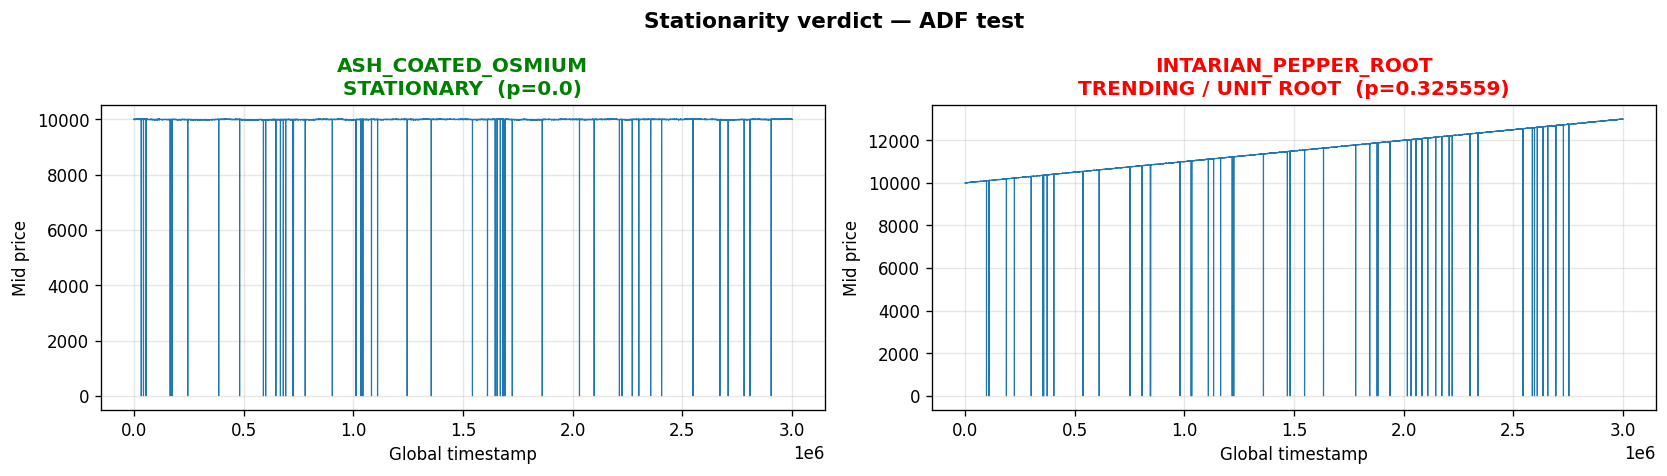

In [7]:
# Visual summary — price level + ADF verdict banner
fig, axes = plt.subplots(1, len(products), figsize=(7 * len(products), 4), squeeze=False)

for ax, product in zip(axes[0], products):
    sub = prices[prices['product'] == product]
    row = adf_df.loc[product]
    color = 'green' if row['verdict'] == 'STATIONARY' else 'red'

    ax.plot(sub['global_ts'], sub['mid_price'], lw=0.7)
    ax.set_title(f"{product}\n{row['verdict']}  (p={row['p-value']})",
                 color=color, fontweight='bold')
    ax.set_xlabel('Global timestamp')
    ax.set_ylabel('Mid price')
    ax.grid(alpha=0.3)

plt.suptitle('Stationarity verdict — ADF test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

| Product | Likely behaviour | Strategy implication |
|---------|-----------------|----------------------|
| ASH_COATED_OSMIUM | See ADF verdict above | If stationary → `StaticProductTrader`; if trending → `DynamicProductTrader` |
| INTARIAN_PEPPER_ROOT | See ADF verdict above | Same logic |

**Key signals to watch:**
- If rolling std is stable over time → price is range-bound → market-make around fair value
- If rolling std is expanding → momentum / trend regime → follow with EMA
- Significant ACF at lag 1 → returns are predictable → mean-reversion or momentum edge exists